## Plot of `block_scan`

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 1.75
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.75
_MARKERS = ["o", "^", "s", "X"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}


In [41]:
# Select plot parameters

# dtype = "int8"
dtype = "fp16"
tiles = [32, 64, 128]

In [42]:
def add_stats_siso(df, nbytes_out_dtype: int):
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * (df["in_bytes_per_elem"] + nbytes_out_dtype)
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [43]:
PREFIX_PATH = "../../.."

df_copy = pd.read_csv(f"{PREFIX_PATH}/bench_results_copy_{dtype}.csv")
df_copy["S"] = "memcopy"
add_stats_siso(df_copy, 2)


df_cast = pd.read_csv(f"{PREFIX_PATH}/bench_results_cast_{dtype}.csv")
df_cast["S"] = "cast (fp16->fp32)"
add_stats_siso(df_cast, 4)


df_block_scan = pd.read_csv(f"{PREFIX_PATH}/bench_results_block_scan_128_{dtype}.csv")
df_block_scan["S"] = f"MCSCANUL1 (Up-Sweep, len: $s^2$)"
df_row_scan = pd.read_csv(f"{PREFIX_PATH}/bench_results_row_scan_128_{dtype}.csv")
df_row_scan["S"] = f"MCSCAN (Up-Sweep, len: $s$)"

df_mcscan = pd.read_csv(f"{PREFIX_PATH}/bench_results_mcscan_128_{dtype}.csv")
df_mcscan["S"] = f"MC-SCAN"

df_scan_multi_cube = pd.read_csv(f"{PREFIX_PATH}/bench_results_scan_multi_cube_128_{dtype}.csv")
df_scan_multi_cube["S"] = f"MCSCANUL1"


# df_tiled = pd.concat([df_block_scan, df_mcscan, df_row_scan, df_scan_multi_cube])
df_tiled = pd.concat([df_block_scan, df_row_scan])

add_stats_siso(df_tiled, 4)

df_no_copy = pd.concat([df_cast, df_tiled])
df_no_cast = pd.concat([df_copy, df_tiled])

## Paper plots

/tmp/ipykernel_3269486/3938902628.py:1: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  ax = sns.lineplot(data=df_no_copy, x='size', y='gelemps', **_SNS_PARAMS)


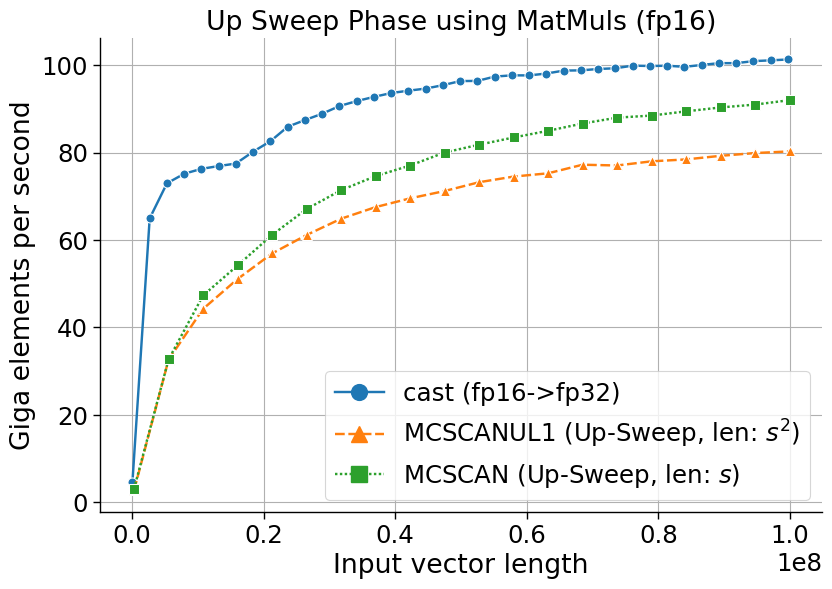

<Figure size 870x627 with 0 Axes>

In [44]:
ax = sns.lineplot(data=df_no_copy, x='size', y='gelemps', **_SNS_PARAMS)

ax.set_title(f"Up Sweep Phase using MatMuls ({dtype})")
ax.set_xlabel("Input vector length")
ax.set_ylabel("Giga elements per second")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()
plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/block_vs_row_scan_gelemsps_{dtype}.png")
plt.show()
plt.clf()

/tmp/ipykernel_3269486/4010203388.py:1: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  ax = sns.lineplot(data=df_no_copy, x='size', y='bw_gbps', **_SNS_PARAMS)


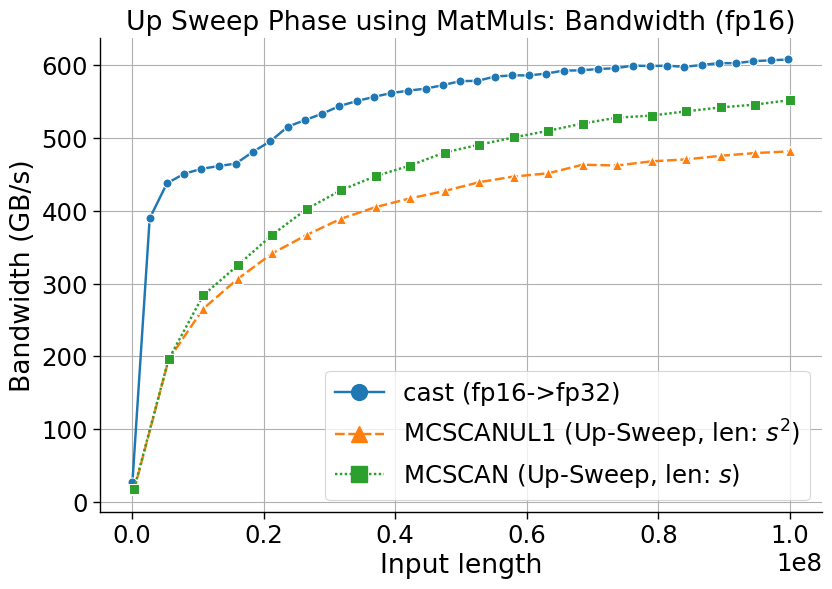

<Figure size 870x627 with 0 Axes>

In [45]:
ax = sns.lineplot(data=df_no_copy, x='size', y='bw_gbps', **_SNS_PARAMS)

ax.set_title(f"Up Sweep Phase using MatMuls: Bandwidth ({dtype})")
ax.set_xlabel("Input length")
ax.set_ylabel("Bandwidth (GB/s)")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/block_vs_row_scan_bw_{dtype}.png")
plt.show()
plt.clf()
